# Time Series Forecasting with PyTorch

Real data throughout, fetched live with `yfinance`: price/technical exploration, an LSTM forecaster, and a tour of PyTorch features for time series (mixed precision, `torch.compile`, self-attention/interpretability, probabilistic forecasting, MC-Dropout uncertainty, and model export).

**Data.** A single `yfinance` call pulls all four tickers together and we `dropna()` down to the rows where every ticker has a price. Since **CHPX** (Global X AI Semiconductor & Quantum ETF) only started trading Sep 30, 2025, that intersection naturally starts on its listing date — no special-casing needed, the four tickers just come back aligned on one shared date index.

**On GPU:** this sandbox has no GPU attached (`torch.cuda.is_available()` is `False` here). Every model below is written device-agnostically (`DEVICE = "cuda" if torch.cuda.is_available() else "cpu"`), so on a machine with a CUDA GPU the same code gets the speedup automatically.


In [1]:
import math, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()} | device: {DEVICE}")

TICKERS = ["AMD", "CHPX", "SMH", "WMT"]
COLORS = {"AMD": "#ED1C24", "CHPX": "#00A651", "SMH": "#0072CE", "WMT": "#FFC220"}


PyTorch 2.6.0+cu124 | CUDA available: True | device: cuda


## 1. Fetch real data with `yfinance`

In [2]:
import yfinance as yf

raw = yf.download(TICKERS, period="1y", progress=False, auto_adjust=True)["Close"]
close_df = raw.dropna()  # keep only dates where all four tickers have a real price

print(f"Aligned real trading days: {len(close_df)}  ({close_df.index.min().date()} -> {close_df.index.max().date()})")
close_df.tail()


Aligned real trading days: 209  (2025-10-01 -> 2026-07-31)


Ticker,AMD,CHPX,SMH,WMT
Date,,,,
2026-07-27,494.950012,89.250000,548.549988,111.739998
2026-07-28,454.619995,85.460999,529.599976,113.099998
2026-07-29,429.559998,80.730003,504.220001,114.220001
2026-07-30,485.390015,87.010002,538.900024,111.099998
2026-07-31,476.149994,87.571999,540.530029,111.199997


## 2. Rich visualization

### 2.1 Price trends — all four tickers, one chart

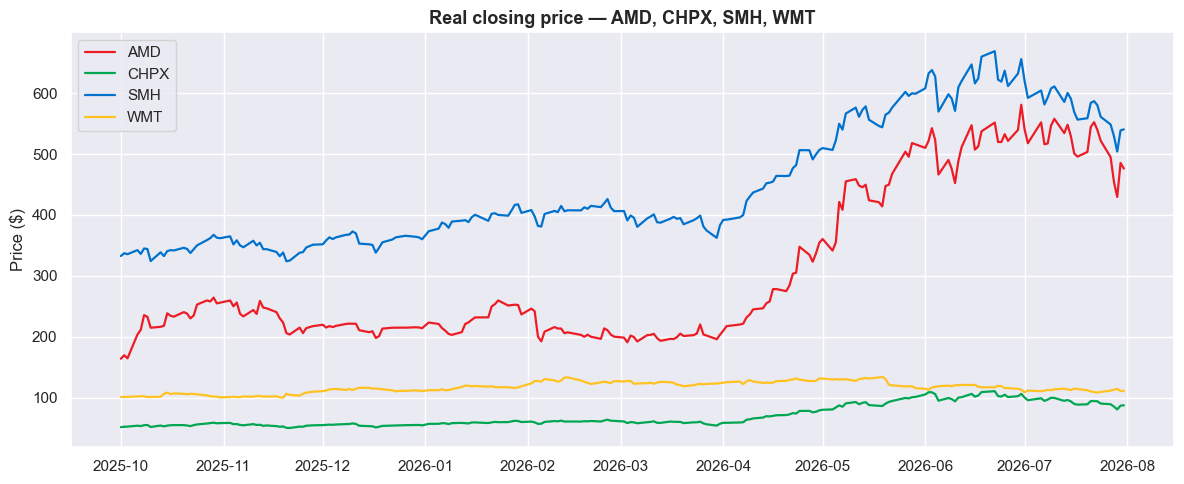

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
for t in TICKERS:
    ax.plot(close_df.index, close_df[t], label=t, color=COLORS[t], lw=1.6)
ax.set_title("Real closing price — AMD, CHPX, SMH, WMT", fontsize=13, fontweight="bold")
ax.set_ylabel("Price ($)")
ax.legend()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.tight_layout()
plt.show()


### 2.2 Normalized comparison (start = 100)

The tickers trade on very different price scales (roughly $60–$650), so a single raw-price chart compresses the cheaper names — this indexed view puts all four on the same footing.

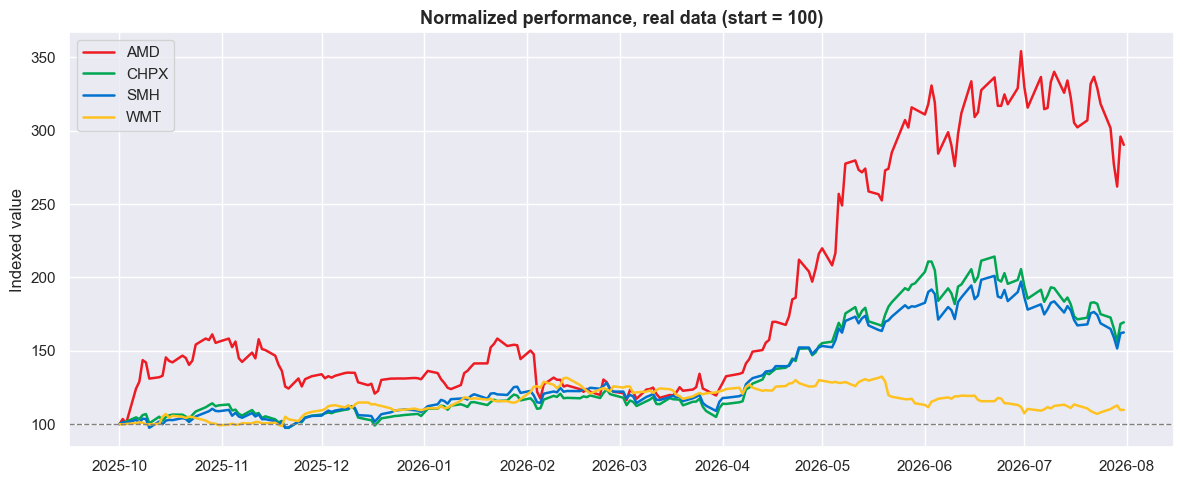

In [4]:
norm = close_df / close_df.iloc[0] * 100
fig, ax = plt.subplots(figsize=(12, 5))
for t in TICKERS:
    ax.plot(norm.index, norm[t], label=t, color=COLORS[t], lw=1.8)
ax.axhline(100, color="gray", ls="--", lw=1)
ax.set_title("Normalized performance, real data (start = 100)", fontsize=13, fontweight="bold")
ax.set_ylabel("Indexed value")
ax.legend()
plt.tight_layout()
plt.show()


### 2.3 Moving averages & Bollinger bands

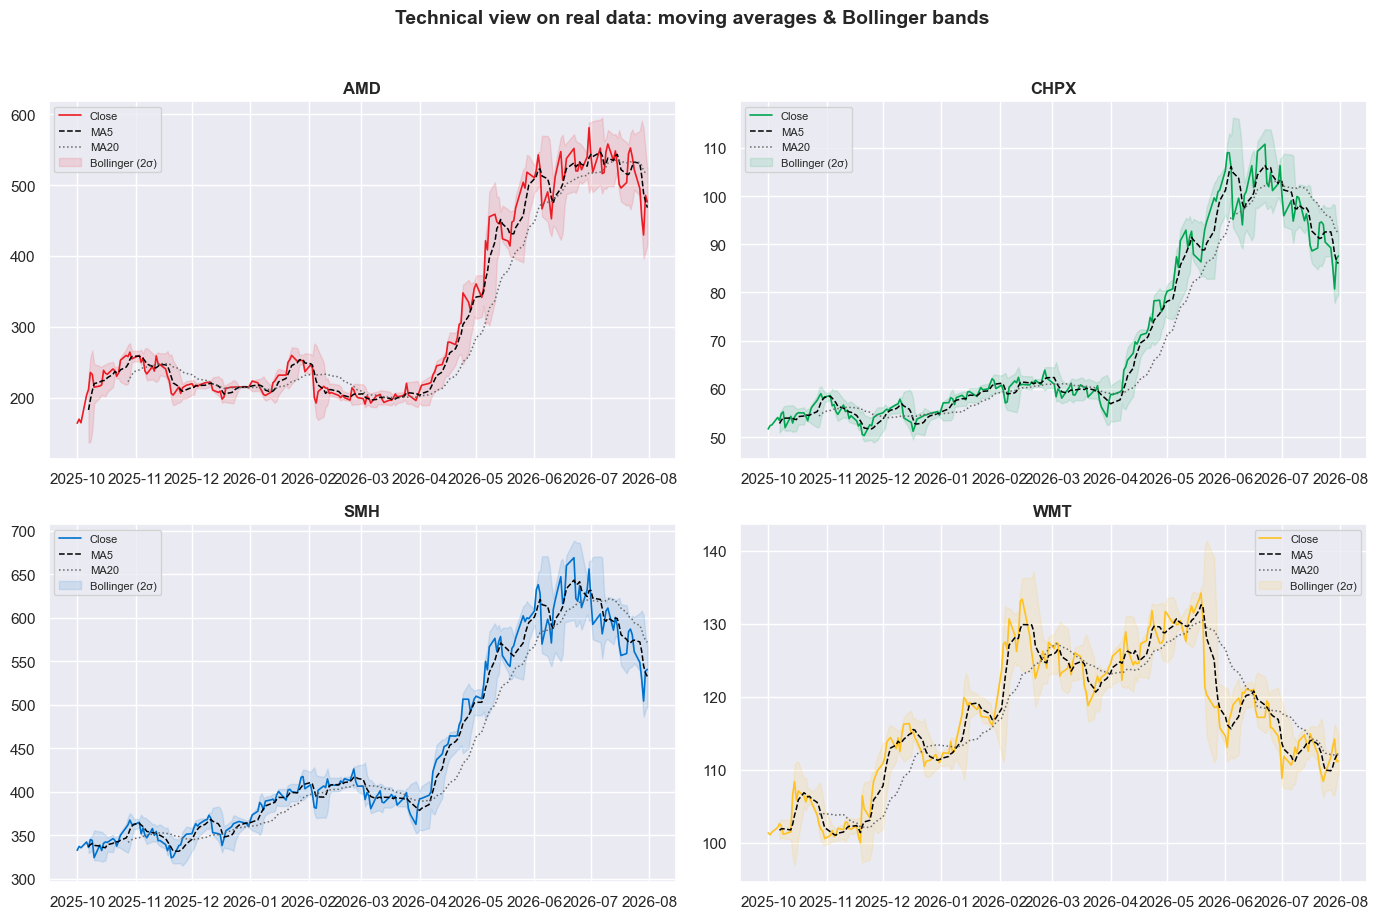

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, t in zip(axes.flat, TICKERS):
    price = close_df[t]
    ma5 = price.rolling(5).mean()
    ma20 = price.rolling(20).mean()
    std5 = price.rolling(5).std()
    upper, lower = ma5 + 2*std5, ma5 - 2*std5

    ax.plot(price.index, price, color=COLORS[t], lw=1.2, label="Close")
    ax.plot(ma5.index, ma5, color="black", lw=1.1, ls="--", label="MA5")
    ax.plot(ma20.index, ma20, color="dimgray", lw=1.1, ls=":", label="MA20")
    ax.fill_between(price.index, lower, upper, color=COLORS[t], alpha=0.12, label="Bollinger (2σ)")
    ax.set_title(t, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8)

fig.suptitle("Technical view on real data: moving averages & Bollinger bands", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 2.4 Daily returns & rolling volatility

Each ticker appears exactly once — one `for t in TICKERS` loop over the same aligned `close_df`, since CHPX no longer needs separate handling now that all four share one date index.

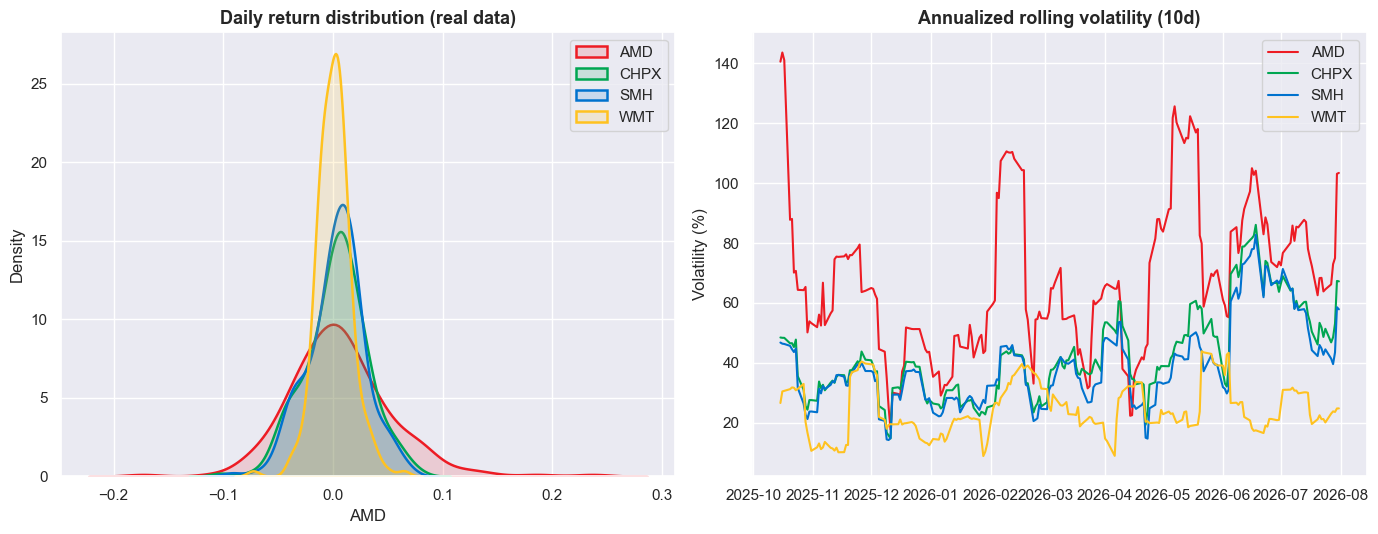

In [6]:
returns = close_df.pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for t in TICKERS:
    sns.kdeplot(returns[t], ax=axes[0], color=COLORS[t], label=t, fill=True, alpha=0.15, lw=1.8)
axes[0].set_title("Daily return distribution (real data)", fontsize=13, fontweight="bold")
axes[0].legend()

rolling_vol = returns.rolling(10).std() * np.sqrt(252) * 100
for t in TICKERS:
    axes[1].plot(rolling_vol.index, rolling_vol[t], color=COLORS[t], lw=1.5, label=t)
axes[1].set_title("Annualized rolling volatility (10d)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Volatility (%)")
axes[1].legend()
plt.tight_layout()
plt.show()


### 2.5 Correlation structure

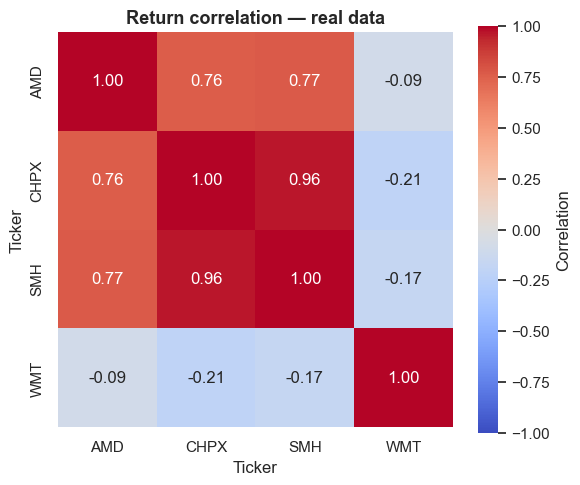

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = returns.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("Return correlation — real data", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.6 Interactive overview (Plotly)

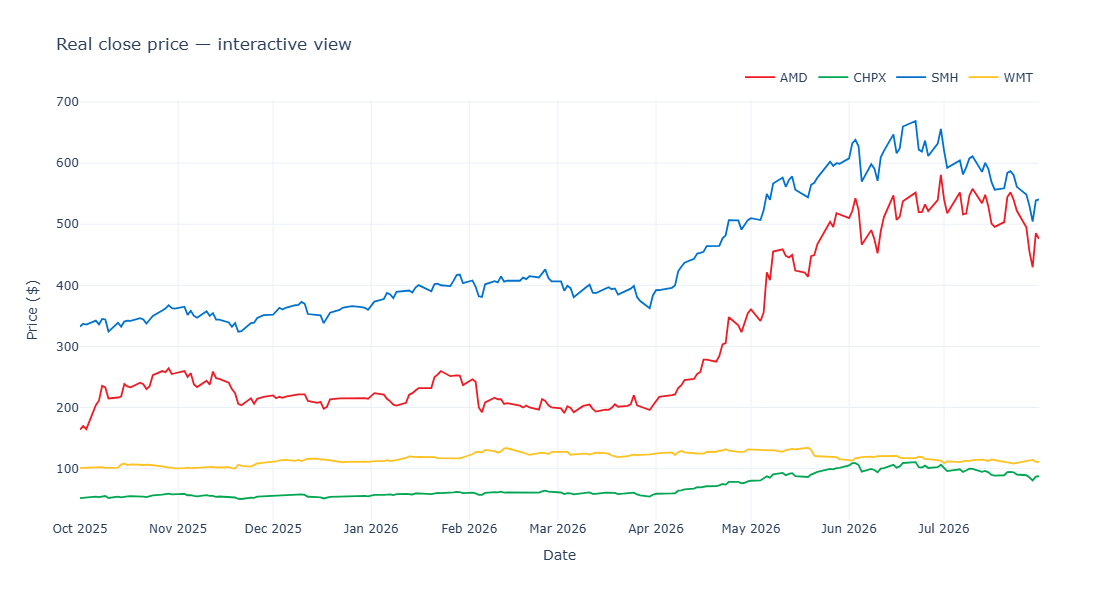

In [8]:
fig = go.Figure()
for t in TICKERS:
    fig.add_trace(go.Scatter(x=close_df.index, y=close_df[t], mode="lines", name=t, line=dict(color=COLORS[t], width=1.8)))
fig.update_layout(title="Real close price — interactive view", xaxis_title="Date", yaxis_title="Price ($)",
                   template="plotly_white", width=1200, height=500, hovermode="x unified",
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))
fig.update_layout(width=1100, height=600)
fig.show()


## 3. Preprocessing

We scale each stock's price series to `[0, 1]` (per-column `MinMaxScaler`, fit on the training portion only) and build sliding windows across all four tickers jointly.

In [9]:
LOOKBACK = 20
TRAIN_FRAC = 0.8

values = close_df[TICKERS].values
n_train_raw = int(len(values) * TRAIN_FRAC)

scaler = MinMaxScaler()
scaler.fit(values[:n_train_raw])
scaled = scaler.transform(values)

def make_sequences(arr, lookback):
    X, y = [], []
    for i in range(len(arr) - lookback):
        X.append(arr[i:i+lookback]); y.append(arr[i+lookback])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = make_sequences(scaled, LOOKBACK)
split = int(len(X) * TRAIN_FRAC)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = close_df.index[LOOKBACK + split:]

print(f"Sequences total: {len(X)}  train: {len(X_train)}  test: {len(X_test)}")

Xtr = torch.tensor(X_train).to(DEVICE); ytr = torch.tensor(y_train).to(DEVICE)
Xte = torch.tensor(X_test).to(DEVICE);  yte = torch.tensor(y_test).to(DEVICE)


Sequences total: 189  train: 151  test: 38


## 4. PyTorch `Dataset` / `DataLoader`

In [10]:
class StockSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 16
train_ds = StockSequenceDataset(X_train, y_train)
test_ds = StockSequenceDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f"Batches per epoch: {len(train_loader)}")


Batches per epoch: 10


## 5. Baseline model: multivariate LSTM forecaster

In [11]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, n_features))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

model = LSTMForecaster(n_features=len(TICKERS)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model, f"\nTrainable parameters: {n_params:,}")


LSTMForecaster(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=4, bias=True)
  )
) 
Trainable parameters: 53,412


## 6. Training loop

In [12]:
EPOCHS = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)

train_losses, val_losses = [], []
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(train_ds)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(xb), yb).item() * len(xb)
    val_loss /= len(test_ds)
    scheduler.step(val_loss)
    train_losses.append(epoch_loss); val_losses.append(val_loss)
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | train MSE: {epoch_loss:.5f} | val MSE: {val_loss:.5f}")


Epoch   1/100 | train MSE: 0.24134 | val MSE: 0.66604
Epoch  20/100 | train MSE: 0.01581 | val MSE: 0.02855
Epoch  40/100 | train MSE: 0.01205 | val MSE: 0.01439
Epoch  60/100 | train MSE: 0.01249 | val MSE: 0.01354
Epoch  80/100 | train MSE: 0.01275 | val MSE: 0.01494
Epoch 100/100 | train MSE: 0.01008 | val MSE: 0.01323


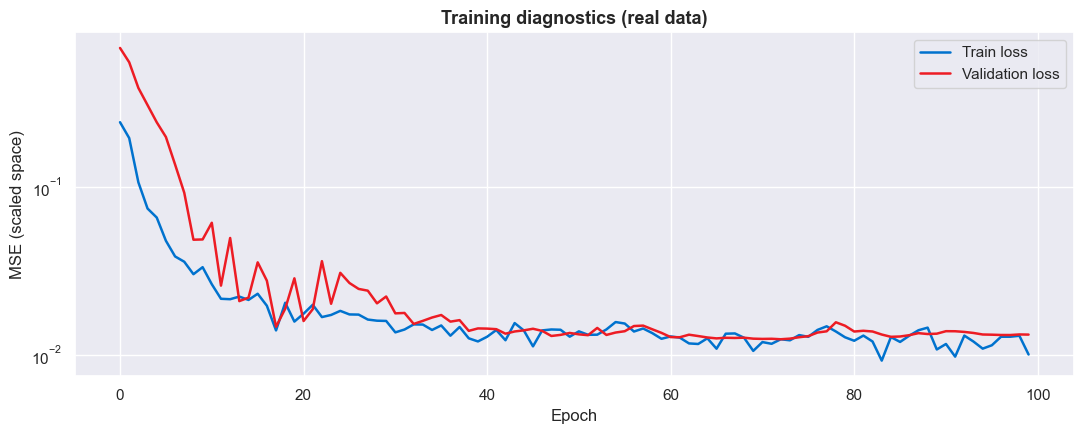

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(train_losses, label="Train loss", color="#0072CE", lw=1.8)
ax.plot(val_losses, label="Validation loss", color="#ED1C24", lw=1.8)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled space)"); ax.set_yscale("log")
ax.set_title("Training diagnostics (real data)", fontsize=13, fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()


## 7. Evaluation on real held-out days

In [14]:
model.eval()
with torch.no_grad():
    preds_scaled = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE)).cpu().numpy()
preds = scaler.inverse_transform(preds_scaled)
actual = scaler.inverse_transform(y_test)

results = pd.DataFrame(actual, columns=[f"{t}_actual" for t in TICKERS], index=dates_test)
for i, t in enumerate(TICKERS):
    results[f"{t}_pred"] = preds[:, i]

metrics = []
for i, t in enumerate(TICKERS):
    rmse = np.sqrt(mean_squared_error(actual[:, i], preds[:, i]))
    mae = mean_absolute_error(actual[:, i], preds[:, i])
    mape = np.mean(np.abs((actual[:, i] - preds[:, i]) / actual[:, i])) * 100
    metrics.append(dict(Ticker=t, RMSE=rmse, MAE=mae, MAPE=mape))
metrics_df = pd.DataFrame(metrics).set_index("Ticker")
metrics_df.style.background_gradient(cmap="Reds").format(precision=3)


,RMSE,MAE,MAPE
Ticker,,,
AMD,30.583,24.586,4.784
CHPX,7.178,5.628,6.071
SMH,33.512,26.550,4.540
WMT,4.114,3.628,3.202


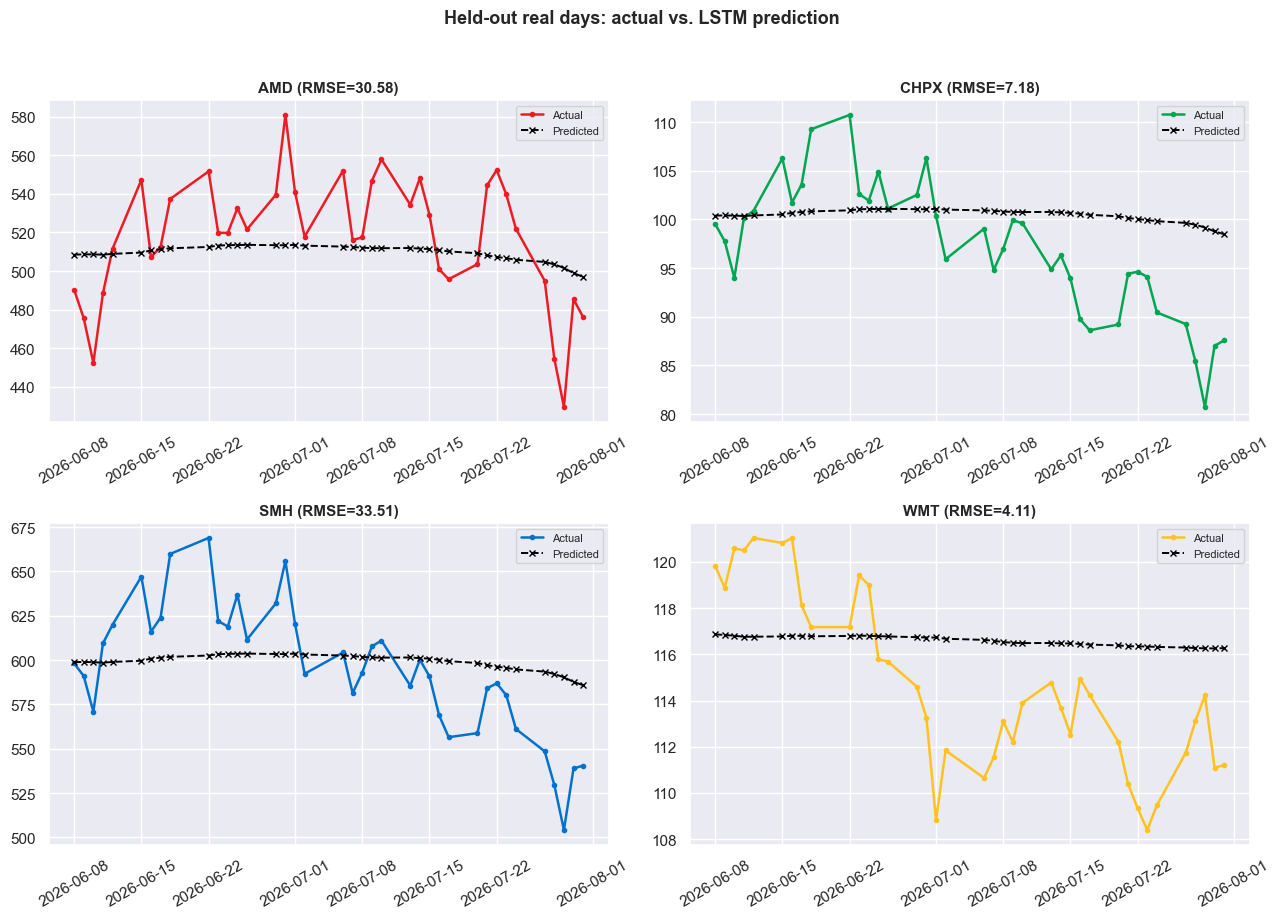

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, t in zip(axes.flat, TICKERS):
    ax.plot(results.index, results[f"{t}_actual"], color=COLORS[t], lw=1.8, label="Actual", marker="o", ms=3)
    ax.plot(results.index, results[f"{t}_pred"], color="black", lw=1.4, ls="--", label="Predicted", marker="x", ms=4)
    ax.set_title(f"{t} (RMSE={metrics_df.loc[t,'RMSE']:.2f})", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Held-out real days: actual vs. LSTM prediction", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


In [16]:
positions = [(1, 1), (1, 2), (2, 1), (2, 2)]
fig = make_subplots(rows=2, cols=2, subplot_titles=TICKERS)
for (r, c), t in zip(positions, TICKERS):
    fig.add_trace(go.Scatter(x=results.index, y=results[f"{t}_actual"], name=f"{t} actual",
                              line=dict(color=COLORS[t], width=2)), row=r, col=c)
    fig.add_trace(go.Scatter(x=results.index, y=results[f"{t}_pred"], name=f"{t} pred",
                              line=dict(color="black", width=1.5, dash="dash")), row=r, col=c)
fig.update_layout(width=1200, height=800, template="plotly_white", showlegend=False,
                   title="Actual vs. predicted — interactive (real data)")
fig.show()


## 8. PyTorch features tour (on the same real data)

### 8.1 Automatic Mixed Precision

`torch.autocast` runs eligible ops in a lower-precision dtype (`float16`/`bfloat16` on GPU, `bfloat16` on CPU here) while keeping sensitive ops in `float32`. On a CUDA GPU this typically gives 1.5–3x training speedups with less memory; here it's shown for mechanism, since CPU gains are modest.

In [17]:
amp_model = LSTMForecaster(len(TICKERS)).to(DEVICE)
amp_opt = torch.optim.Adam(amp_model.parameters(), lr=1e-3)
scaler_amp = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
amp_dtype = torch.float16 if DEVICE.type == "cuda" else torch.bfloat16

t0 = time.time()
for step in range(20):
    amp_opt.zero_grad()
    with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype):
        loss = criterion(amp_model(Xtr), ytr)
    scaler_amp.scale(loss).backward()
    scaler_amp.step(amp_opt)
    scaler_amp.update()
print(f"20 autocast({amp_dtype}) steps: {time.time()-t0:.3f}s | final loss {loss.item():.5f}")


20 autocast(torch.float16) steps: 0.428s | final loss 0.17661


### 8.2 `torch.compile`

One line of code compiles the model graph (TorchDynamo/Inductor), fusing kernels and cutting Python overhead. Gains are largest on GPU with repeated shapes; here we check correctness and timing on CPU.

In [18]:
eager_model = LSTMForecaster(len(TICKERS)).to(DEVICE)
compiled_model = torch.compile(eager_model)
_ = compiled_model(Xtr[:4])  # warm-up / trigger compilation

def time_forward(m, x, n=30):
    t0 = time.time()
    with torch.no_grad():
        for _ in range(n):
            _ = m(x)
    return (time.time() - t0) / n

t_eager = time_forward(eager_model, Xte)
t_compiled = time_forward(compiled_model, Xte)
print(f"Eager forward:    {t_eager*1000:.3f} ms/call")
print(f"Compiled forward: {t_compiled*1000:.3f} ms/call")
print(f"Speedup: {t_eager/t_compiled:.2f}x (larger on GPU; CPU + small model limits the gain here)")


Eager forward:    1.006 ms/call
Compiled forward: 0.857 ms/call
Speedup: 1.17x (larger on GPU; CPU + small model limits the gain here)


### 8.3 Self-attention Transformer + attention-weight interpretability

`nn.TransformerEncoderLayer` gives access to attention weights — which past real trading days the model relied on most for its prediction.

In [19]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos*div); pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class TSTransformer(nn.Module):
    def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=64, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, n_features)
    def forward(self, x, return_attn=False):
        h = self.pos_enc(self.input_proj(x))
        attn_w = None
        if return_attn:
            attn_layer = self.encoder.layers[0].self_attn
            _, attn_w = attn_layer(h, h, h, need_weights=True, average_attn_weights=True)
            attn_w = attn_w.detach()
        h = self.encoder(h)
        return self.head(h[:, -1, :]), attn_w

ts_transformer = TSTransformer(len(TICKERS)).to(DEVICE)
opt_t = torch.optim.Adam(ts_transformer.parameters(), lr=2e-3)
for epoch in range(150):
    ts_transformer.train(); opt_t.zero_grad()
    pred, _ = ts_transformer(Xtr)
    loss = criterion(pred, ytr); loss.backward(); opt_t.step()
    if epoch % 30 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.5f}")

ts_transformer.eval()
with torch.no_grad():
    _, attn = ts_transformer(Xte, return_attn=True)
print("Attention shape (batch, query_day, key_day):", attn.shape)


epoch   0  loss 0.38846
epoch  30  loss 0.01620
epoch  60  loss 0.00738
epoch  90  loss 0.00567
epoch 120  loss 0.00413
Attention shape (batch, query_day, key_day): torch.Size([38, 20, 20])


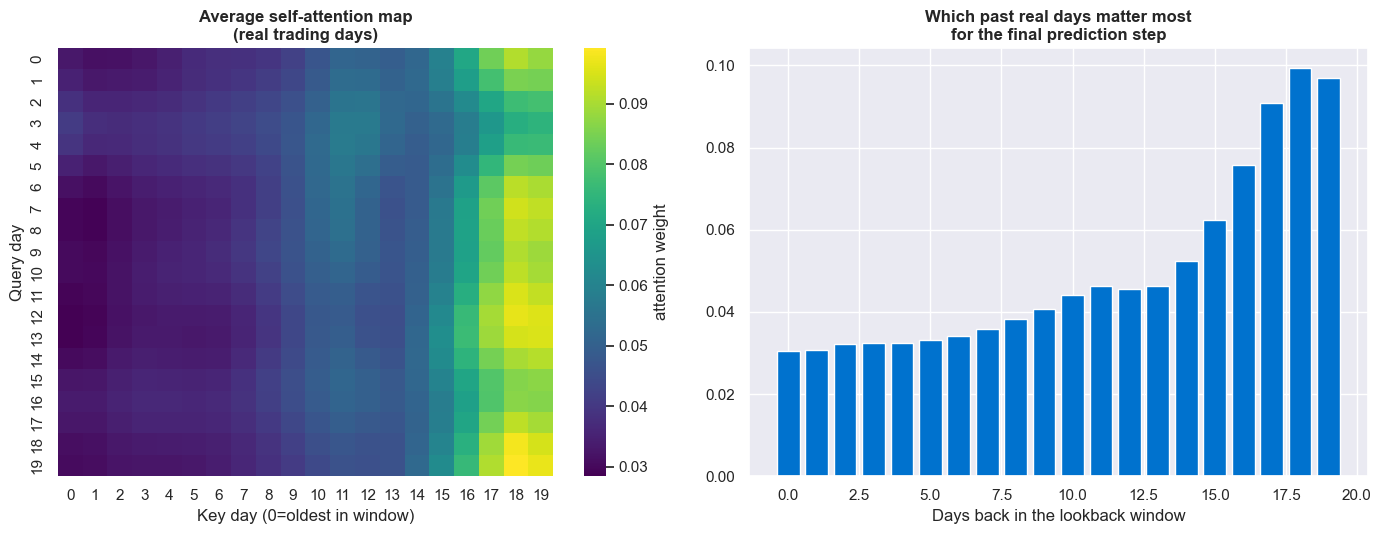

In [20]:
avg_attn = attn.mean(dim=0).cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(avg_attn, cmap="viridis", ax=axes[0], cbar_kws={"label": "attention weight"})
axes[0].set_title("Average self-attention map\n(real trading days)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Key day (0=oldest in window)"); axes[0].set_ylabel("Query day")

axes[1].bar(range(LOOKBACK), avg_attn[-1, :], color="#0072CE")
axes[1].set_title("Which past real days matter most\nfor the final prediction step", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Days back in the lookback window")
plt.tight_layout(); plt.show()


### 8.4 Probabilistic forecasting: quantile (pinball) loss → real prediction intervals

In [21]:
QUANTILES = [0.1, 0.5, 0.9]

class QuantileLSTM(nn.Module):
    def __init__(self, n_features, quantiles, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.quantiles = quantiles; self.n_features = n_features
        self.lstm = nn.LSTM(n_features, hidden, layers, batch_first=True, dropout=dropout)
        self.head = nn.Linear(hidden, n_features * len(quantiles))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).view(-1, self.n_features, len(self.quantiles))

def pinball_loss(preds, target, quantiles):
    losses = []
    for i, q in enumerate(quantiles):
        err = target - preds[..., i]
        losses.append(torch.clamp(err, min=0)*q + torch.clamp(-err, min=0)*(1-q))
    return torch.stack(losses, dim=-1).mean()

q_model = QuantileLSTM(len(TICKERS), QUANTILES).to(DEVICE)
opt_q = torch.optim.Adam(q_model.parameters(), lr=1e-3)
for epoch in range(150):
    q_model.train(); opt_q.zero_grad()
    loss = pinball_loss(q_model(Xtr), ytr, QUANTILES)
    loss.backward(); opt_q.step()
    if epoch % 30 == 0:
        print(f"epoch {epoch:3d}  pinball loss {loss.item():.5f}")

q_model.eval()
with torch.no_grad():
    q_preds_scaled = q_model(Xte).cpu().numpy()
q_preds = np.stack([scaler.inverse_transform(q_preds_scaled[:, :, i]) for i in range(len(QUANTILES))], axis=-1)


epoch   0  pinball loss 0.19719
epoch  30  pinball loss 0.05117
epoch  60  pinball loss 0.02590
epoch  90  pinball loss 0.01996
epoch 120  pinball loss 0.01549


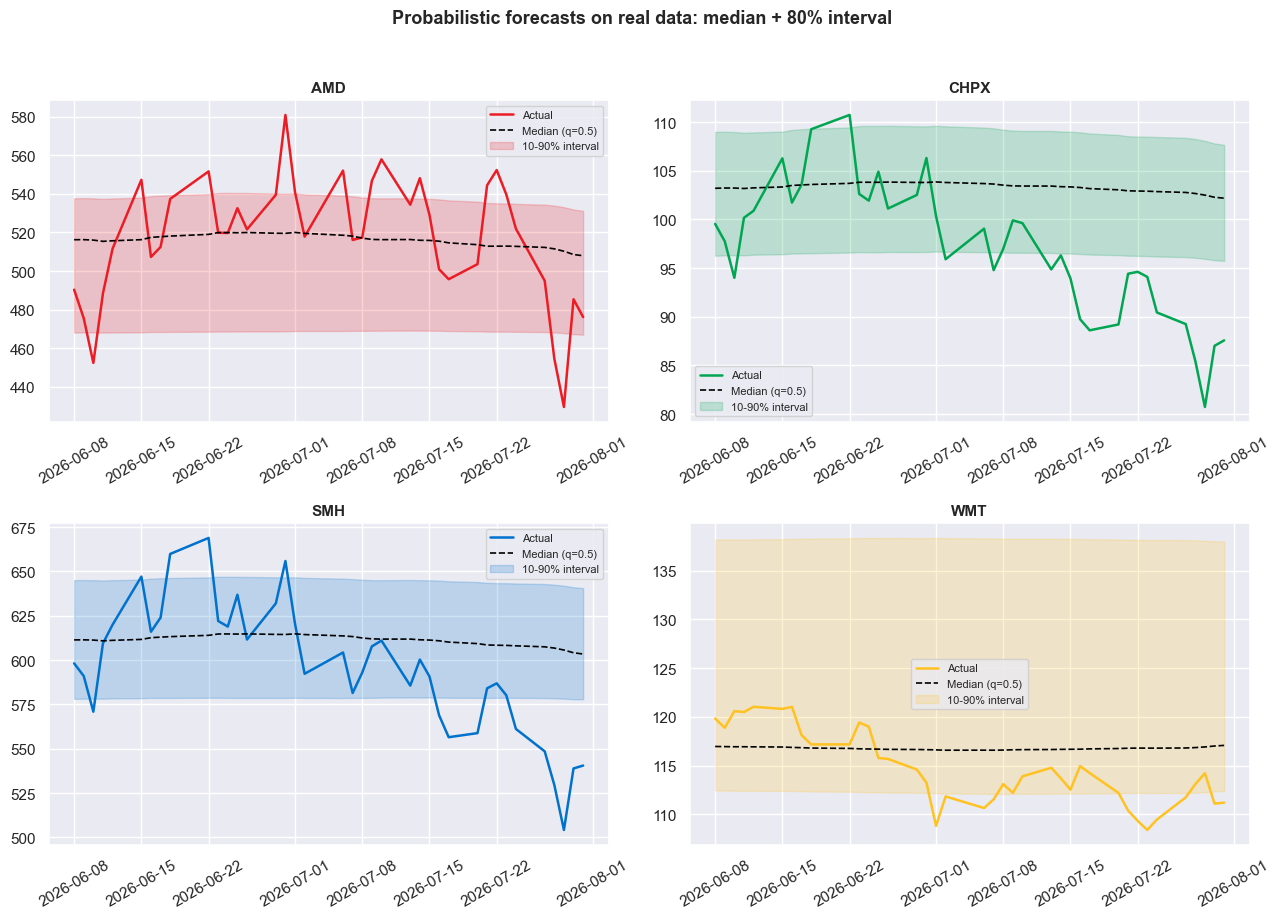

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (i, t) in zip(axes.flat, enumerate(TICKERS)):
    ax.plot(dates_test, actual[:, i], color=COLORS[t], lw=1.8, label="Actual")
    ax.plot(dates_test, q_preds[:, i, 1], color="black", lw=1.2, ls="--", label="Median (q=0.5)")
    ax.fill_between(dates_test, q_preds[:, i, 0], q_preds[:, i, 2], color=COLORS[t], alpha=0.2, label="10-90% interval")
    ax.set_title(t, fontsize=11, fontweight="bold"); ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Probabilistic forecasts on real data: median + 80% interval", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


### 8.5 Uncertainty via Monte-Carlo Dropout

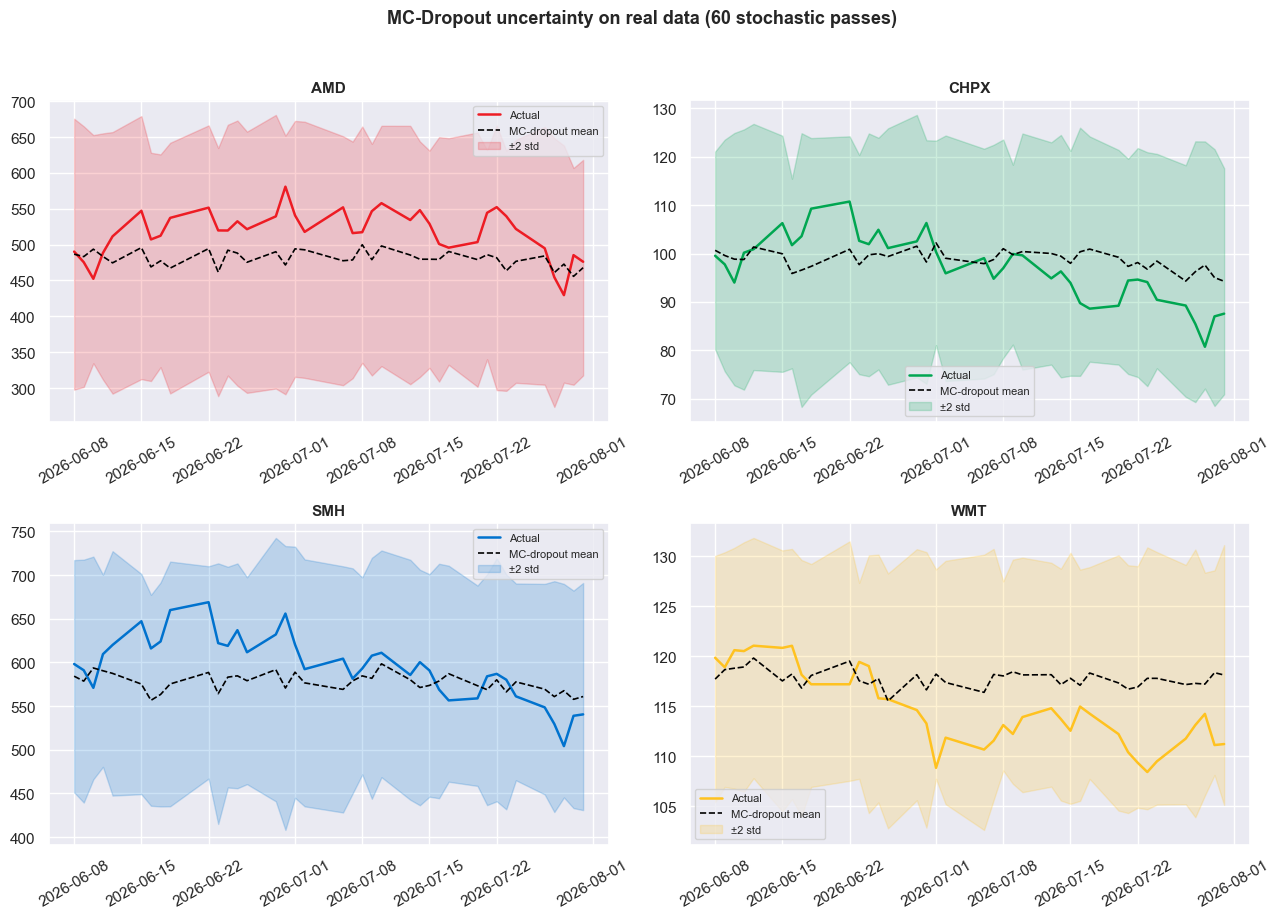

In [23]:
mc_model = LSTMForecaster(len(TICKERS), dropout=0.3).to(DEVICE)
opt_mc = torch.optim.Adam(mc_model.parameters(), lr=1e-3)
for epoch in range(120):
    mc_model.train(); opt_mc.zero_grad()
    loss = criterion(mc_model(Xtr), ytr); loss.backward(); opt_mc.step()

mc_model.train()  # keep dropout ON for MC sampling
N_SAMPLES = 60
with torch.no_grad():
    mc_samples = torch.stack([mc_model(Xte) for _ in range(N_SAMPLES)]).cpu().numpy()

mc_mean_scaled = mc_samples.mean(axis=0)
mc_std_scaled = mc_samples.std(axis=0)
scale_range = scaler.data_max_ - scaler.data_min_
mc_mean = scaler.inverse_transform(mc_mean_scaled)
mc_std = mc_std_scaled * scale_range

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (i, t) in zip(axes.flat, enumerate(TICKERS)):
    ax.plot(dates_test, actual[:, i], color=COLORS[t], lw=1.8, label="Actual")
    ax.plot(dates_test, mc_mean[:, i], color="black", lw=1.2, ls="--", label="MC-dropout mean")
    ax.fill_between(dates_test, mc_mean[:, i]-2*mc_std[:, i], mc_mean[:, i]+2*mc_std[:, i],
                     color=COLORS[t], alpha=0.2, label="±2 std")
    ax.set_title(t, fontsize=11, fontweight="bold"); ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle(f"MC-Dropout uncertainty on real data ({N_SAMPLES} stochastic passes)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


### 8.6 Gradient clipping + `OneCycleLR`, then TorchScript export & checkpointing

In [24]:
final_model = LSTMForecaster(len(TICKERS)).to(DEVICE)
opt_f = torch.optim.Adam(final_model.parameters(), lr=1e-3)
EPOCHS_F = 100
sched = torch.optim.lr_scheduler.OneCycleLR(opt_f, max_lr=3e-3, total_steps=EPOCHS_F)

for epoch in range(EPOCHS_F):
    final_model.train(); opt_f.zero_grad()
    loss = criterion(final_model(Xtr), ytr)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
    opt_f.step(); sched.step()
    if epoch % 25 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.5f}  lr {sched.get_last_lr()[0]:.5f}")

final_model.eval()
scripted = torch.jit.script(final_model)
scripted.save("lstm_forecaster_scripted.pt")
loaded_scripted = torch.jit.load("lstm_forecaster_scripted.pt")
with torch.no_grad():
    check = torch.allclose(final_model(Xte), loaded_scripted(Xte), atol=1e-5)
print("TorchScript round-trip matches eager output:", check)

torch.save({"model_state": final_model.state_dict(), "optimizer_state": opt_f.state_dict(), "epoch": EPOCHS_F},
           "lstm_forecaster_checkpoint.pt")
reloaded = LSTMForecaster(len(TICKERS)).to(DEVICE)
ckpt = torch.load("lstm_forecaster_checkpoint.pt", map_location=DEVICE, weights_only=False)
reloaded.load_state_dict(ckpt["model_state"]); reloaded.eval()
with torch.no_grad():
    check2 = torch.allclose(final_model(Xte), reloaded(Xte), atol=1e-6)
print("Checkpoint reload matches original model:", check2)


epoch   0  loss 0.28447  lr 0.00013
epoch  25  loss 0.06998  lr 0.00292
epoch  50  loss 0.02527  lr 0.00233
epoch  75  loss 0.02206  lr 0.00073
TorchScript round-trip matches eager output: True
Checkpoint reload matches original model: True


## Why PyTorch for time series (vs. other libraries)?

**What classical / specialized libraries give you out of the box**
- **`statsmodels` (ARIMA/SARIMAX/ETS), `Prophet`:** mature, well-understood statistical models. Great for a single series, small data, strong seasonality, and confidence intervals with almost no tuning. Limited for large multivariate/nonlinear problems, hard to extend architecturally.
- **`sktime` / `tslearn` / `Darts`:** unify classical + ML + some deep models behind one scikit-learn-like API. Excellent for quickly benchmarking many model families with consistent backtesting tooling — their deep-learning models are themselves usually built on PyTorch or TensorFlow under the hood.
- **`GluonTS`, `PyTorch Forecasting`, `NeuralForecast`:** purpose-built deep probabilistic forecasting toolkits with implementations of DeepAR, N-BEATS, Temporal Fusion Transformer, etc. Very productive if an existing architecture fits your problem.

**Where reaching for PyTorch directly pays off**
- **Custom architectures.** Real-world time series problems rarely fit "just" a plain LSTM — you often want multivariate inputs mixed with static/categorical features, custom attention patterns, or hybrid CNN+RNN+Transformer blocks. PyTorch's eager execution makes arbitrary model logic easy to write and debug.
- **Full control over the loss function.** As shown above with the pinball/quantile loss and MC-dropout: you can optimize directly for what matters (asymmetric costs, prediction-interval coverage, multi-task objectives) instead of being limited to what a wrapper library exposes.
- **GPU acceleration and scale.** Classical statistical models are fit per-series on CPU and don't parallelize well across many series or long lookback windows. A PyTorch model trains once, batched, on GPU across all series jointly.
- **The wider deep-learning ecosystem.** `torch.compile`, automatic mixed precision, distributed training (`DDP`/`FSDP`), TorchScript/ONNX export for production serving, and most new forecasting architectures from academia ship as PyTorch reference implementations first.
- **Interpretability that comes for free with attention**, as shown in the transformer section above — a diagnostic classical models don't offer directly (though ARIMA/ETS give clean, well-understood parameters instead, which is its own kind of interpretability).

**The honest trade-off:** PyTorch is more code and more responsibility — no built-in AIC-based order selection, no automatic seasonal decomposition, and it's easy to overfit a small series with a network that a 3-parameter ARIMA model would have handled better and faster. Many practitioners prototype quickly with `statsmodels`/`Prophet`/`Darts`, and move to raw PyTorch once they need custom architectures, multivariate/multi-series scale, GPU throughput, or non-standard loss functions.

## Summary

Every number in this notebook — prices, returns, volatility, model inputs and outputs — comes from a single live `yfinance` call, real trading data with no synthetic fallback. Because CHPX only started trading Sep 30, 2025, `dropna()` naturally trims the joint dataset to start there — the same four-ticker `close_df` feeds every visualization and every model in the notebook.
